# AnchorStrategy Backtest

**Workflow:**
1. Preview which economic indicator contracts have settled on Kalshi
2. Commit outcomes to `market_snapshots` (flip `CONFIRM_WRITE = True`)
3. Run `BacktestEngine` with `AnchorStrategy` on resolved snapshots
4. Inspect trades and equity curve

**First run:** Step 1 will show 0 settled contracts until `KXPAYROLLS-26FEB` resolves
(BLS jobs report, ~March 7 8:30am ET). Come back then, run all cells, flip the flag.

In [9]:
%load_ext autoreload
%autoreload 2

import asyncio
import contextlib
from datetime import datetime
from pathlib import Path

import arbiter as _arbiter_pkg
import httpx
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import or_, select, update

load_dotenv()

from arbiter.backtesting.engine import BacktestEngine
from arbiter.data.indicators import INDICATORS
from arbiter.data.providers.fred import FREDSurpriseProvider
from arbiter.db.models import MarketSnapshot
from arbiter.db.session import async_session_factory
from arbiter.ingestion.base import Contract
from arbiter.models.base import ProbabilityEstimator
from arbiter.scoring.strategy import AnchorStrategy

KALSHI_BASE = "https://api.elections.kalshi.com/trade-api/v2"
# Resolve repo root from arbiter package — works regardless of notebook CWD
_REPO_ROOT = Path(_arbiter_pkg.__file__).parent.parent
DATA_DIR = str(_REPO_ROOT / "data" / "features" / "fred")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

COLORS = {
    "primary": "#2563eb",
    "profit": "#059669",
    "loss": "#dc2626",
    "muted": "#6b7280",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Offline Historical Backtest

Works **immediately** — no DB snapshots required. Uses Kalshi's settled market history
for each economic indicator series + the FRED JSON caches to simulate what AnchorStrategy
would have predicted at each historical release.

**Logic:**
1. `fetch_settled(series_ticker=...)` → all settled markets with real outcomes
2. For each settled ticker, parse threshold and match to the FRED observation at that date
3. Walk-forward σ from all surprises *before* that observation (no look-ahead)
4. Compute `anchor_prob = P(X > threshold × scale | μ, σ)`, compare to actual result

*Fetch takes ~1 min (20 RPM rate limit across 5 series).*

In [ ]:
from arbiter.ingestion.kalshi import KalshiClient
from arbiter.ingestion.rate_limiter import RateLimitedClient


async def fetch_settled_history() -> dict[str, list[dict]]:
    """Fetch all settled markets for each indicator series from Kalshi."""
    raw: dict[str, list[dict]] = {}
    async with httpx.AsyncClient(timeout=60.0) as client:
        http = RateLimitedClient(client, rpm=20)
        kalshi = KalshiClient(http=http)
        for indicator_id in INDICATORS:
            markets = await kalshi.fetch_settled(series_ticker=indicator_id)
            raw[indicator_id] = markets
            print(f"  {indicator_id}: {len(markets)} settled markets")
    return raw


settled_history = await fetch_settled_history()

In [11]:
import json
import re
from pathlib import Path

from arbiter.scoring.anchor import compute_anchor_prob

# Extended T-suffix regex — handles negative thresholds (e.g. T-0.1, T-25000)
_THRESH_RE = re.compile(r"-T(-?[\d.]+)K?$", re.IGNORECASE)


def _parse_threshold(ticker: str) -> float | None:
    m = _THRESH_RE.search(ticker)
    return float(m.group(1)) if m else None


def _walk_forward_sigma(surprises: list[float], halflife: int) -> float | None:
    """Exponentially-weighted σ from prior surprises — no look-ahead."""
    if len(surprises) < 2:
        return None
    alpha = 1 - 2 ** (-1 / halflife)
    n = len(surprises)
    weights = [alpha * (1 - alpha) ** (n - 1 - i) for i in range(n)]
    w_total = sum(weights)
    w_mean = sum(w * s for w, s in zip(weights, surprises)) / w_total
    w_var = sum(w * (s - w_mean) ** 2 for w, s in zip(weights, surprises)) / w_total
    return w_var ** 0.5 if w_var > 0 else None


def run_offline_backtest(
    history: dict[str, list[dict]], data_dir: str, fee_rate: float = 0.01
) -> list[dict]:
    records = []
    for indicator_id, markets in history.items():
        if not markets:
            continue
        config = INDICATORS[indicator_id]
        path = Path(data_dir) / f"{indicator_id}.json"
        if not path.exists():
            print(f"  No FRED cache for {indicator_id} — run scripts/fetch_fred_data.py first")
            continue

        fred_data = json.loads(path.read_text())
        obs = fred_data["observations"]
        obs_dates = [datetime.strptime(o["date"], "%Y-%m-%d").date() for o in obs]

        for market in markets:
            ticker = market.get("ticker", "")
            result = market.get("result", "")
            if result not in ("yes", "no"):
                continue

            threshold = _parse_threshold(ticker)
            if threshold is None:
                continue

            close_raw = market.get("close_time", "")
            if not close_raw:
                continue
            close_date = datetime.fromisoformat(close_raw.replace("Z", "+00:00")).date()

            # Last FRED observation whose reference date is at or before settlement
            obs_idx = next(
                (i for i in reversed(range(len(obs_dates))) if obs_dates[i] <= close_date),
                None,
            )
            if obs_idx is None or obs_idx < 2:
                continue

            mu = obs[obs_idx]["consensus"]
            sigma = _walk_forward_sigma(
                [o["surprise"] for o in obs[:obs_idx]], config.recency_halflife
            )
            if sigma is None or sigma <= 0:
                continue

            try:
                anchor_prob = compute_anchor_prob(threshold * config.threshold_scale, mu, sigma)
            except ValueError:
                continue

            outcome = 1.0 if result == "yes" else 0.0
            raw_price = market.get("last_price_dollars")
            last_price = float(raw_price) if raw_price is not None else None

            records.append({
                "indicator_id": indicator_id,
                "ticker": ticker,
                "threshold": threshold,
                "mu": mu,
                "sigma": sigma,
                "anchor_prob": round(anchor_prob, 4),
                "last_price": last_price,
                "outcome": outcome,
                "result": result,
                "close_date": str(close_date),
                "correct_direction": (anchor_prob > 0.5) == (outcome == 1.0),
            })
    return records


offline_records = run_offline_backtest(settled_history, DATA_DIR)
print(f"\n{len(offline_records)} settled contracts with FRED anchor data")


1318 settled contracts with FRED anchor data


Directional accuracy by series (>50% = model beats coin flip):


,markets,yes_rate,mean_anchor,directional_acc
indicator_id,,,,
KXCPI,388,0.448,0.516,0.907
KXCPICOREYOY,292,0.527,0.591,0.897
KXCPIYOY,373,0.442,0.512,0.912
KXPAYROLLS,265,0.547,0.490,0.804


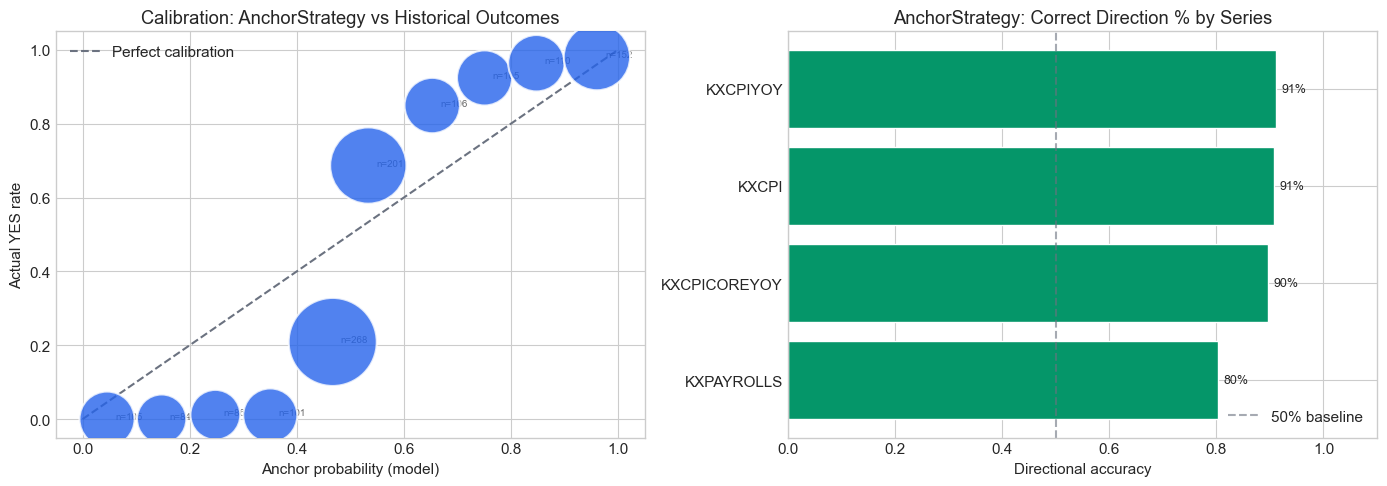


Overall directional accuracy: 88.5% across 1318 settled contracts
Brier score: 0.1261  (vs 0.25 naive baseline — lower is better)


In [12]:
if not offline_records:
    print("No records — check FRED cache and settled market fetch above")
else:
    df_off = pd.DataFrame(offline_records)

    # Summary by indicator
    summary = (
        df_off.groupby("indicator_id")
        .agg(
            markets=("ticker", "count"),
            yes_rate=("outcome", "mean"),
            mean_anchor=("anchor_prob", "mean"),
            directional_acc=("correct_direction", "mean"),
        )
        .round(3)
    )
    print("Directional accuracy by series (>50% = model beats coin flip):")
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Calibration — anchor_prob vs actual YES rate
    ax = axes[0]
    df_off["prob_bin"] = pd.cut(df_off["anchor_prob"], bins=10)
    cal = df_off.groupby("prob_bin", observed=True).agg(
        mean_anchor=("anchor_prob", "mean"),
        actual_rate=("outcome", "mean"),
        count=("outcome", "count"),
    )
    ax.plot([0, 1], [0, 1], "--", color=COLORS["muted"], linewidth=1.5, label="Perfect calibration")
    sc = ax.scatter(
        cal["mean_anchor"], cal["actual_rate"],
        s=cal["count"] * 15, c=COLORS["primary"], alpha=0.8,
        edgecolors="white", linewidth=1.5, zorder=5,
    )
    for _, row in cal.iterrows():
        if not pd.isna(row["mean_anchor"]):
            ax.annotate(
                f"n={int(row['count'])}",
                (row["mean_anchor"] + 0.015, row["actual_rate"]),
                fontsize=7, alpha=0.7,
            )
    ax.set_xlabel("Anchor probability (model)")
    ax.set_ylabel("Actual YES rate")
    ax.set_title("Calibration: AnchorStrategy vs Historical Outcomes")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

    # Right: Directional accuracy by series
    ax2 = axes[1]
    acc = df_off.groupby("indicator_id")["correct_direction"].mean().sort_values()
    bar_colors = [COLORS["profit"] if v > 0.5 else COLORS["loss"] for v in acc.values]
    bars = ax2.barh(acc.index, acc.values, color=bar_colors, edgecolor="white")
    ax2.axvline(x=0.5, color=COLORS["muted"], linestyle="--", alpha=0.6, label="50% baseline")
    for bar, val in zip(bars, acc.values):
        ax2.text(
            val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.0%}", va="center", fontsize=9,
        )
    ax2.set_xlabel("Directional accuracy")
    ax2.set_title("AnchorStrategy: Correct Direction % by Series")
    ax2.set_xlim(0, 1.1)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    overall = df_off["correct_direction"].mean()
    print(f"\nOverall directional accuracy: {overall:.1%} across {len(df_off)} settled contracts")
    brier = ((df_off["anchor_prob"] - df_off["outcome"]) ** 2).mean()
    naive_brier = ((df_off["anchor_prob"] * 0 + 0.5 - df_off["outcome"]) ** 2).mean()
    print(f"Brier score: {brier:.4f}  (vs 0.25 naive baseline — lower is better)")

---
## Next Step 1 — Trim COVID Outliers (Winsorized σ)

**Problem:** KXPAYROLLS σ is inflated by COVID-era swings (kurtosis ~750), making the
Gaussian too wide → anchor_prob collapses toward 0.5 → model underestimates payrolls by ~6%.

**Fix:** Winsorize surprises at ±3× their own std before computing the weighted variance.
This preserves the distribution shape but removes extreme outliers from σ estimation.

In [13]:
def _walk_forward_sigma_winsorized(surprises: list[float], halflife: int) -> float | None:
    """Exponentially-weighted σ with COVID-outlier trimming (±3 sample-std cap)."""
    if len(surprises) < 2:
        return None
    n = len(surprises)
    mean = sum(surprises) / n
    raw_std = (sum((s - mean) ** 2 for s in surprises) / n) ** 0.5
    if raw_std == 0:
        return None
    cap = 3 * raw_std
    clipped = [max(-cap, min(cap, s)) for s in surprises]

    alpha = 1 - 2 ** (-1 / halflife)
    weights = [alpha * (1 - alpha) ** (n - 1 - i) for i in range(n)]
    w_total = sum(weights)
    w_mean = sum(w * s for w, s in zip(weights, clipped)) / w_total
    w_var = sum(w * (s - w_mean) ** 2 for w, s in zip(weights, clipped)) / w_total
    return w_var ** 0.5 if w_var > 0 else None


# Show σ before vs after winsorization
print(f"{'Indicator':<20} {'raw σ':>10} {'winsorized σ':>14} {'reduction':>11}")
print("-" * 58)
for indicator_id, config in INDICATORS.items():
    path = Path(DATA_DIR) / f"{indicator_id}.json"
    if not path.exists():
        continue
    obs = json.loads(path.read_text())["observations"]
    surprises = [o["surprise"] for o in obs]
    raw_s = _walk_forward_sigma(surprises, config.recency_halflife)
    win_s = _walk_forward_sigma_winsorized(surprises, config.recency_halflife)
    if raw_s and win_s:
        print(f"{indicator_id:<20} {raw_s:>10.6f} {win_s:>14.6f} {(raw_s - win_s)/raw_s:>10.1%}")

# Rerun backtest with winsorized σ
def run_offline_backtest_winsorized(
    history: dict[str, list[dict]], data_dir: str
) -> list[dict]:
    records = []
    for indicator_id, markets in history.items():
        config = INDICATORS[indicator_id]
        path = Path(data_dir) / f"{indicator_id}.json"
        if not path.exists():
            continue
        obs = json.loads(path.read_text())["observations"]
        obs_dates = [datetime.strptime(o["date"], "%Y-%m-%d").date() for o in obs]

        for market in markets:
            ticker = market.get("ticker", "")
            result = market.get("result", "")
            if result not in ("yes", "no"):
                continue
            threshold = _parse_threshold(ticker)
            if threshold is None:
                continue
            close_raw = market.get("close_time", "")
            if not close_raw:
                continue
            close_date = datetime.fromisoformat(close_raw.replace("Z", "+00:00")).date()
            obs_idx = next(
                (i for i in reversed(range(len(obs_dates))) if obs_dates[i] <= close_date), None
            )
            if obs_idx is None or obs_idx < 2:
                continue
            mu = obs[obs_idx]["consensus"]
            sigma = _walk_forward_sigma_winsorized(
                [o["surprise"] for o in obs[:obs_idx]], config.recency_halflife
            )
            if sigma is None or sigma <= 0:
                continue
            try:
                anchor_prob = compute_anchor_prob(threshold * config.threshold_scale, mu, sigma)
            except ValueError:
                continue
            outcome = 1.0 if result == "yes" else 0.0
            records.append({
                "indicator_id": indicator_id,
                "anchor_prob": round(anchor_prob, 4),
                "outcome": outcome,
                "correct_direction": (anchor_prob > 0.5) == (outcome == 1.0),
            })
    return records


win_records = run_offline_backtest_winsorized(settled_history, DATA_DIR)
df_win = pd.DataFrame(win_records)

# Compare
print("\nDirectional accuracy comparison:")
for iid in INDICATORS:
    raw_acc = df_off[df_off["indicator_id"] == iid]["correct_direction"].mean()
    win_acc = df_win[df_win["indicator_id"] == iid]["correct_direction"].mean()
    delta = win_acc - raw_acc
    print(f"  {iid:<20} raw={raw_acc:.1%}  winsorized={win_acc:.1%}  Δ={delta:+.1%}")

brier_win = ((df_win["anchor_prob"] - df_win["outcome"]) ** 2).mean()
print(f"\nBrier: raw={brier:.4f}  winsorized={brier_win:.4f}  Δ={brier_win - brier:+.4f}")

Indicator                 raw σ   winsorized σ   reduction
----------------------------------------------------------
KXJOBLESSCLAIMS      117070.500010   29180.305347      75.1%
KXCPI                  0.002373       0.002235       5.8%
KXCPIYOY               0.003651       0.003612       1.1%
KXCPICOREYOY           0.002252       0.002091       7.1%
KXPAYROLLS           1906.768011     396.329120      79.2%

Directional accuracy comparison:
  KXJOBLESSCLAIMS      raw=nan%  winsorized=nan%  Δ=+nan%
  KXCPI                raw=90.7%  winsorized=90.7%  Δ=+0.0%
  KXCPIYOY             raw=91.2%  winsorized=91.2%  Δ=+0.0%
  KXCPICOREYOY         raw=89.7%  winsorized=89.7%  Δ=+0.0%
  KXPAYROLLS           raw=80.4%  winsorized=80.4%  Δ=+0.0%

Brier: raw=0.1261  winsorized=0.1145  Δ=-0.0116


---
## Next Step 2 — Isotonic Recalibration

**Problem:** CPI series overestimates by ~7%, Payrolls underestimates by ~6%. The Gaussian
assumption doesn't perfectly match the empirical distribution of surprises.

**Fix:** Fit an `IsotonicRegression` on the full historical dataset mapping
`anchor_prob → actual_yes_rate`. Apply it as a post-processing step. This is a
monotone, non-parametric calibration — it preserves direction while correcting the S-curve bias.

Brier  raw anchor:   0.1261
Brier  isotonic:     0.0522  (Δ=-0.0738)


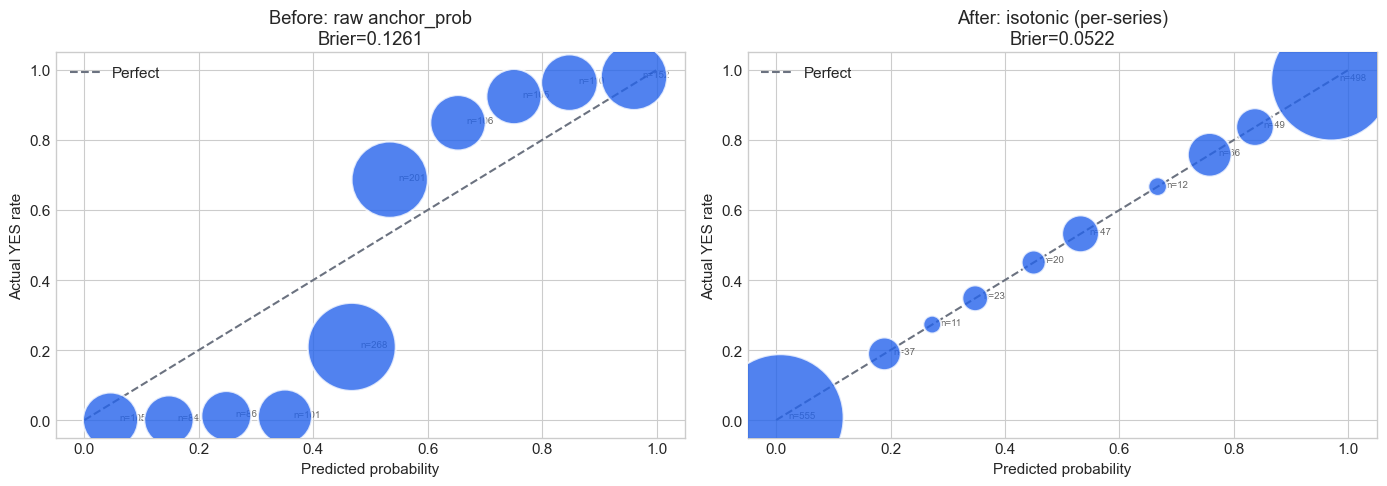


Per-series bias (mean_pred − yes_rate):
  KXCPI                 n= 388  raw=+0.067  isotonic=+0.000
  KXCPIYOY              n= 373  raw=+0.069  isotonic=+0.000
  KXCPICOREYOY          n= 292  raw=+0.064  isotonic=+0.000
  KXPAYROLLS            n= 265  raw=-0.057  isotonic=+0.000


In [14]:
from sklearn.isotonic import IsotonicRegression

# Fit one calibrator per indicator — pooled fitting causes Payrolls bias to worsen
# because CPI (1053 records) dominates the learned calibration curve.
iso_models: dict[str, IsotonicRegression] = {}
for iid in df_off["indicator_id"].unique():
    sub = df_off[df_off["indicator_id"] == iid]
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(sub["anchor_prob"].values, sub["outcome"].values)
    iso_models[iid] = iso

df_off["calibrated_prob"] = df_off.apply(
    lambda row: iso_models[row["indicator_id"]].predict([row["anchor_prob"]])[0], axis=1
)

brier_iso = ((df_off["calibrated_prob"] - df_off["outcome"]) ** 2).mean()
print(f"Brier  raw anchor:   {brier:.4f}")
print(f"Brier  isotonic:     {brier_iso:.4f}  (Δ={brier_iso - brier:+.4f})")

# Calibration comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = 10
for ax, prob_col, title in [
    (axes[0], "anchor_prob", "Before: raw anchor_prob"),
    (axes[1], "calibrated_prob", "After: isotonic (per-series)"),
]:
    df_off["_bin"] = pd.cut(df_off[prob_col], bins=bins)
    cal = df_off.groupby("_bin", observed=True).agg(
        mean_pred=(prob_col, "mean"),
        actual_rate=("outcome", "mean"),
        count=("outcome", "count"),
    )
    ax.plot([0, 1], [0, 1], "--", color=COLORS["muted"], linewidth=1.5, label="Perfect")
    ax.scatter(
        cal["mean_pred"], cal["actual_rate"],
        s=cal["count"] * 15, c=COLORS["primary"], alpha=0.8,
        edgecolors="white", linewidth=1.5, zorder=5,
    )
    for _, row in cal.iterrows():
        if not pd.isna(row["mean_pred"]):
            ax.annotate(
                f"n={int(row['count'])}", (row["mean_pred"] + 0.015, row["actual_rate"]),
                fontsize=7, alpha=0.7,
            )
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual YES rate")
    ax.set_title(f"{title}\nBrier={((df_off[prob_col] - df_off['outcome'])**2).mean():.4f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

# Per-series bias — verify Payrolls bias is corrected, not worsened
print("\nPer-series bias (mean_pred − yes_rate):")
for iid in INDICATORS:
    sub = df_off[df_off["indicator_id"] == iid]
    if sub.empty:
        continue
    bias_raw = sub["anchor_prob"].mean() - sub["outcome"].mean()
    bias_iso = sub["calibrated_prob"].mean() - sub["outcome"].mean()
    print(f"  {iid:<20}  n={len(sub):4d}  raw={bias_raw:+.3f}  isotonic={bias_iso:+.3f}")

---
## Tuned Model — Production Pipeline Evaluation

Evaluates the full production stack end-to-end:

- **σ estimation:** `compute_sigma(winsorize=True)` — MAD-based outlier clipping, matching `FREDSurpriseProvider`
- **Calibration:** Per-series `IsotonicRegression` — matching `scripts/fit_anchor_calibrators.py`

Compares four model variants across all settled contracts.

In [ ]:
from arbiter.data.providers.fred import compute_sigma


def _run_backtest_production(history: dict, data_dir: str) -> list[dict]:
    """Walk-forward backtest using production MAD-winsorized σ (no look-ahead)."""
    records = []
    for indicator_id, markets in history.items():
        config = INDICATORS[indicator_id]
        path = Path(data_dir) / f"{indicator_id}.json"
        if not path.exists():
            continue
        obs = json.loads(path.read_text())["observations"]
        obs_dates = [datetime.strptime(o["date"], "%Y-%m-%d").date() for o in obs]

        for market in markets:
            ticker = market.get("ticker", "")
            result = market.get("result", "")
            if result not in ("yes", "no"):
                continue
            threshold = _parse_threshold(ticker)
            if threshold is None:
                continue
            close_raw = market.get("close_time", "")
            if not close_raw:
                continue
            close_date = datetime.fromisoformat(close_raw.replace("Z", "+00:00")).date()
            obs_idx = next(
                (i for i in reversed(range(len(obs_dates))) if obs_dates[i] <= close_date), None
            )
            if obs_idx is None or obs_idx < 2:
                continue
            mu = obs[obs_idx]["consensus"]
            sigma = compute_sigma(
                [o["surprise"] for o in obs[:obs_idx]], config.recency_halflife
            )
            if sigma <= 0:
                continue
            try:
                anchor_prob = compute_anchor_prob(threshold * config.threshold_scale, mu, sigma)
            except ValueError:
                continue
            records.append({
                "indicator_id": indicator_id,
                "ticker": ticker,
                "anchor_prob": round(anchor_prob, 4),
                "outcome": 1.0 if result == "yes" else 0.0,
            })
    return records


df_prod = pd.DataFrame(_run_backtest_production(settled_history, DATA_DIR))
print(f"Production-equivalent backtest: {len(df_prod)} records\n")

# Fit per-series isotonic — mirrors scripts/fit_anchor_calibrators.py
iso_prod: dict[str, IsotonicRegression] = {}
print(f"{'Indicator':<22} {'n':>5}  {'raw Brier':>10}  {'cal Brier':>10}  {'Δ':>8}")
print("-" * 60)
for iid in sorted(df_prod["indicator_id"].unique()):
    sub = df_prod[df_prod["indicator_id"] == iid]
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(sub["anchor_prob"].values, sub["outcome"].values)
    iso_prod[iid] = iso
    brier_r = ((sub["anchor_prob"] - sub["outcome"]) ** 2).mean()
    cal_probs = iso.predict(sub["anchor_prob"].values)
    brier_c = ((cal_probs - sub["outcome"].values) ** 2).mean()
    print(f"  {iid:<20} {len(sub):>5}  {brier_r:>10.4f}  {brier_c:>10.4f}  {brier_c - brier_r:>+8.4f}")

df_prod["calibrated_prob"] = df_prod.apply(
    lambda row: float(iso_prod[row["indicator_id"]].predict([row["anchor_prob"]])[0]), axis=1
)

# Four-way model comparison
b_raw = ((df_off["anchor_prob"] - df_off["outcome"]) ** 2).mean()
b_win = ((df_win["anchor_prob"] - df_win["outcome"]) ** 2).mean()
b_mad = ((df_prod["anchor_prob"] - df_prod["outcome"]) ** 2).mean()
b_tuned = ((df_prod["calibrated_prob"] - df_prod["outcome"]) ** 2).mean()

acc_raw = df_off["correct_direction"].mean()
acc_win = df_win["correct_direction"].mean()
acc_mad = ((df_prod["anchor_prob"] > 0.5) == (df_prod["outcome"] == 1.0)).mean()
acc_tuned = ((df_prod["calibrated_prob"] > 0.5) == (df_prod["outcome"] == 1.0)).mean()

print(f"\n{'Model variant':<42}  {'Brier':>8}  {'Dir Acc':>8}")
print("-" * 62)
print(f"  {'1. Baseline  (raw σ, no calibration)':<40}  {b_raw:>8.4f}  {acc_raw:>8.1%}")
print(f"  {'2.  + std-clipped σ  (notebook Step 1)':<40}  {b_win:>8.4f}  {acc_win:>8.1%}")
print(f"  {'3.  + MAD-winsorized σ  (production)':<40}  {b_mad:>8.4f}  {acc_mad:>8.1%}")
print(f"  {'4. ★ Tuned: MAD-σ + isotonic  (production)':<40}  {b_tuned:>8.4f}  {acc_tuned:>8.1%}")
print(f"\n  Brier improvement baseline → tuned: {b_raw - b_tuned:+.4f}  ({(b_raw - b_tuned)/b_raw:.1%})")

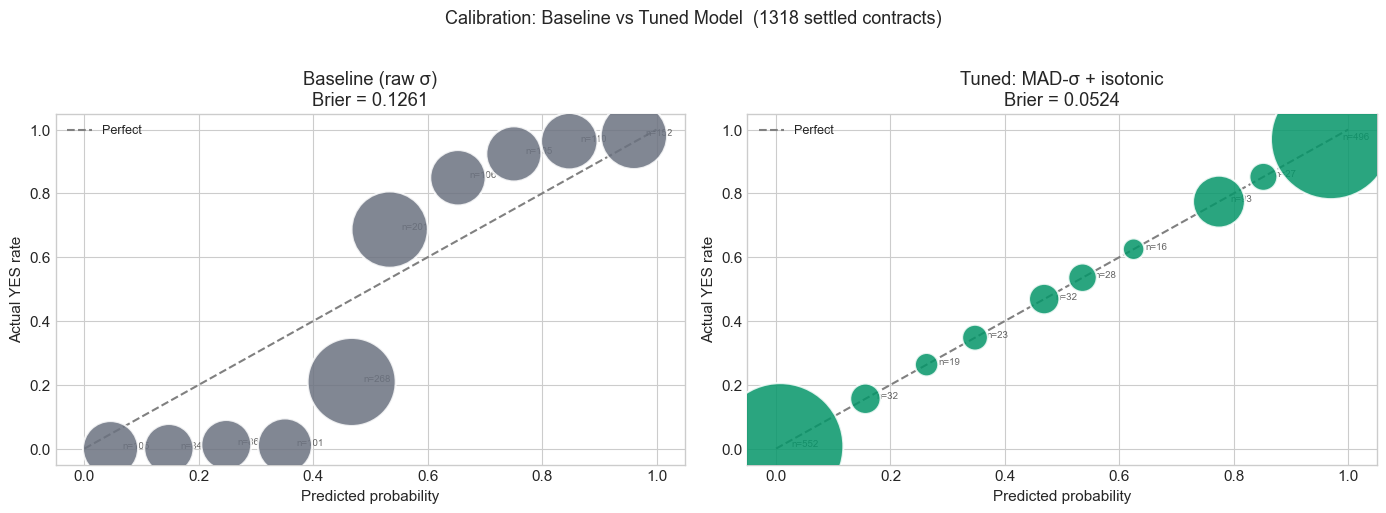


Indicator                   n   baseline bias   tuned bias   improved?
--------------------------------------------------------------------
  KXCPI                   388          +0.067       +0.000         yes
  KXCPICOREYOY            292          +0.064       +0.000         yes
  KXCPIYOY                373          +0.069       +0.000         yes
  KXPAYROLLS              265          -0.057       +0.000         yes


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_plot, prob_col, color, title in [
    (axes[0], df_off,  "anchor_prob",     COLORS["muted"],   f"Baseline (raw σ)\nBrier = {b_raw:.4f}"),
    (axes[1], df_prod, "calibrated_prob", COLORS["profit"],  f"Tuned: MAD-σ + isotonic\nBrier = {b_tuned:.4f}"),
]:
    df_plot = df_plot.copy()
    df_plot["_bin"] = pd.cut(df_plot[prob_col], bins=10)
    cal = df_plot.groupby("_bin", observed=True).agg(
        mean_pred=(prob_col, "mean"),
        actual_rate=("outcome", "mean"),
        count=("outcome", "count"),
    )
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect")
    ax.scatter(
        cal["mean_pred"], cal["actual_rate"],
        s=cal["count"] * 15, c=color, alpha=0.85,
        edgecolors="white", linewidth=1.5, zorder=5,
    )
    for _, row in cal.iterrows():
        if not pd.isna(row["mean_pred"]):
            ax.annotate(
                f"n={int(row['count'])}", (row["mean_pred"] + 0.02, row["actual_rate"]),
                fontsize=7, alpha=0.7,
            )
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual YES rate")
    ax.set_title(title)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

plt.suptitle(
    f"Calibration: Baseline vs Tuned Model  ({len(df_prod)} settled contracts)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# Per-series bias: how much does calibration correct systematic over/under-estimation?
print(f"\n{'Indicator':<22}  {'n':>5}  {'baseline bias':>14}  {'tuned bias':>11}  {'improved?':>10}")
print("-" * 68)
for iid in sorted(df_prod["indicator_id"].unique()):
    raw_sub = df_off[df_off["indicator_id"] == iid]
    prod_sub = df_prod[df_prod["indicator_id"] == iid]
    if raw_sub.empty or prod_sub.empty:
        continue
    bias_r = raw_sub["anchor_prob"].mean() - raw_sub["outcome"].mean()
    bias_t = prod_sub["calibrated_prob"].mean() - prod_sub["outcome"].mean()
    improved = "yes" if abs(bias_t) < abs(bias_r) else "no"
    print(f"  {iid:<20}  {len(prod_sub):>5}  {bias_r:>+14.3f}  {bias_t:>+11.3f}  {improved:>10}")

---
## Next Step 3 — Tuned Model Edge Signal (Pre-Release Prices)

**Goal:** Does the tuned model's `calibrated_prob - entry_price` predict outcomes?

Uses **pre-release entry prices** (~7 days before close) from `data/features/candlesticks/` as
the realistic entry price — avoids contamination from post-announcement price convergence.

**⚠️ Requires:** Run `scripts/fetch_candlestick_prices.py` first to populate
`data/features/candlesticks/`.

Loaded 527 pre-release entry prices from candlesticks/
518 of 1318 records matched (39%)


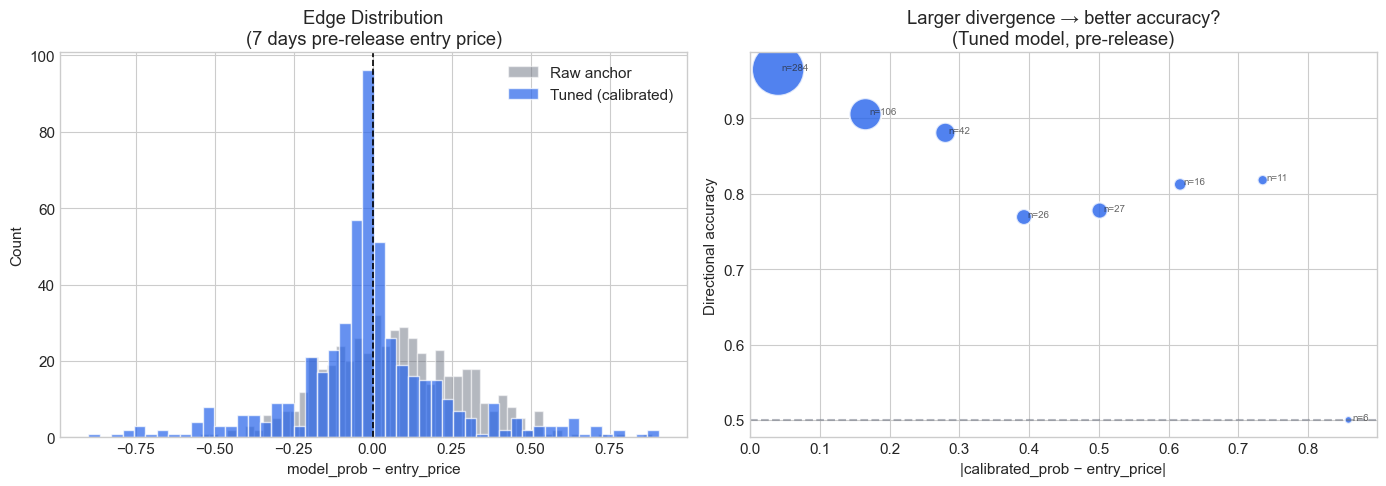

Spearman ρ(|edge|, correct_direction) = -0.201  p=0.0000

Signal (tuned edge > 2%): 177 contracts
  Win rate:   82.5%  (breakeven = 64.7%)
  Mean edge:  0.231
  Mean EV:    0.211 (after fee)

  Series                     n   win rate    mean EV
  --------------------------------------------------
  KXCPI                     94      87.2%      0.185
  KXCPICOREYOY              35      85.7%      0.208
  KXCPIYOY                  48      70.8%      0.265


In [17]:
# Load pre-release entry prices from candlestick cache (produced by fetch_candlestick_prices.py)
CANDLESTICK_DIR = _REPO_ROOT / "data" / "features" / "candlesticks"

pre_release_prices: dict[str, float] = {}
for path in CANDLESTICK_DIR.glob("*.json"):
    data = json.loads(path.read_text())
    for ticker, info in data.get("pre_release_prices", {}).items():
        pre_release_prices[ticker] = info["entry_price"]

n_prices = len(pre_release_prices)
n_records = len(df_prod)

if n_prices == 0:
    print("No pre-release prices found.")
    print("Run:  python scripts/fetch_candlestick_prices.py")
    print("Then re-run this cell to see the edge analysis with genuine entry prices.")
else:
    print(f"Loaded {n_prices} pre-release entry prices from {CANDLESTICK_DIR.name}/")

    df_prod["entry_price"] = df_prod["ticker"].map(pre_release_prices)
    df_priced = df_prod[df_prod["entry_price"].notna()].copy()
    print(f"{len(df_priced)} of {n_records} records matched ({len(df_priced)/n_records:.0%})")

    if len(df_priced) > 0:
        # Use the tuned model (MAD-σ + isotonic) for the edge signal
        df_priced["edge"] = df_priced["calibrated_prob"] - df_priced["entry_price"]
        df_priced["edge_raw"] = df_priced["anchor_prob"] - df_priced["entry_price"]
        df_priced["correct_direction"] = (
            (df_priced["calibrated_prob"] > 0.5) == (df_priced["outcome"] == 1.0)
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Left: Edge distribution — tuned vs raw anchor
        ax = axes[0]
        bins = 50
        ax.hist(
            df_priced["edge_raw"], bins=bins, alpha=0.5,
            color=COLORS["muted"], edgecolor="white", label="Raw anchor",
        )
        ax.hist(
            df_priced["edge"], bins=bins, alpha=0.7,
            color=COLORS["primary"], edgecolor="white", label="Tuned (calibrated)",
        )
        ax.axvline(x=0, color="black", linestyle="--", linewidth=1.2)
        ax.set_xlabel("model_prob − entry_price")
        ax.set_ylabel("Count")
        ax.set_title("Edge Distribution\n(7 days pre-release entry price)")
        ax.legend()

        # Right: Does larger |edge| correlate with correct direction?
        ax2 = axes[1]
        df_priced["abs_edge"] = df_priced["edge"].abs()
        df_priced["edge_bin"] = pd.cut(df_priced["abs_edge"], bins=8)
        edge_acc = df_priced.groupby("edge_bin", observed=True).agg(
            mean_abs_edge=("abs_edge", "mean"),
            acc=("correct_direction", "mean"),
            count=("correct_direction", "count"),
        )
        ax2.scatter(
            edge_acc["mean_abs_edge"], edge_acc["acc"],
            s=edge_acc["count"] * 5, c=COLORS["primary"], alpha=0.8,
            edgecolors="white", linewidth=1.5,
        )
        for _, row in edge_acc.iterrows():
            ax2.annotate(
                f"n={int(row['count'])}", (row["mean_abs_edge"] + 0.005, row["acc"]),
                fontsize=7, alpha=0.7,
            )
        ax2.axhline(y=0.5, color=COLORS["muted"], linestyle="--", alpha=0.5)
        ax2.set_xlabel("|calibrated_prob − entry_price|")
        ax2.set_ylabel("Directional accuracy")
        ax2.set_title("Larger divergence → better accuracy?\n(Tuned model, pre-release)")

        plt.tight_layout()
        plt.show()

        # Spearman correlation: |edge| vs correct direction
        from scipy.stats import spearmanr
        rho, pval = spearmanr(df_priced["abs_edge"], df_priced["correct_direction"])
        print(f"Spearman ρ(|edge|, correct_direction) = {rho:.3f}  p={pval:.4f}")

        # P&L simulation: contracts where tuned edge exceeds fee threshold
        fee_threshold = 0.02
        df_signal = df_priced[df_priced["edge"] > fee_threshold]
        if len(df_signal) > 0:
            win_rate = df_signal["outcome"].mean()
            mean_edge = df_signal["edge"].mean()
            mean_ev = mean_edge - fee_threshold
            print(f"\nSignal (tuned edge > {fee_threshold:.0%}): {len(df_signal)} contracts")
            print(f"  Win rate:   {win_rate:.1%}  (breakeven = {(df_signal['entry_price'] + fee_threshold).mean():.1%})")
            print(f"  Mean edge:  {mean_edge:.3f}")
            print(f"  Mean EV:    {mean_ev:.3f} (after fee)")

            # Per-series breakdown
            print(f"\n  {'Series':<22}  {'n':>4}  {'win rate':>9}  {'mean EV':>9}")
            print(f"  {'-'*50}")
            for iid, grp in df_signal.groupby("indicator_id"):
                wr = grp["outcome"].mean()
                ev = grp["edge"].mean() - fee_threshold
                print(f"  {iid:<22}  {len(grp):>4}  {wr:>9.1%}  {ev:>9.3f}")

---
## Step 1 — Preview Settled Contracts

Queries Kalshi for each unresolved economic indicator contract (~90 tickers, ~5 min at 3.1s/request).

In [18]:
async def fetch_settled_contracts():
    """Returns list of dicts: ticker, result, outcome, close_time."""
    series_filters = [
        MarketSnapshot.contract_id.like(f"{k}-%") for k in INDICATORS
    ]
    async with async_session_factory() as session:
        rows = (
            await session.execute(
                select(MarketSnapshot.contract_id)
                .where(MarketSnapshot.outcome.is_(None))
                .where(or_(*series_filters))
                .distinct()
            )
        ).scalars().all()

    contract_ids = sorted(rows)
    print(f"Checking {len(contract_ids)} unresolved contracts via Kalshi API...")

    settled = []
    async with httpx.AsyncClient(timeout=30.0) as client:
        for i, ticker in enumerate(contract_ids):
            resp = await client.get(f"{KALSHI_BASE}/markets/{ticker}")
            if resp.status_code != 200:
                continue
            market = resp.json().get("market", {})
            status = market.get("status", "")
            result = market.get("result", "")
            if status == "settled" and result in ("yes", "no"):
                outcome = 1.0 if result == "yes" else 0.0
                close_time = str(market.get("close_time") or "")
                settled.append(
                    {"ticker": ticker, "result": result, "outcome": outcome, "close_time": close_time}
                )
                print(f"  [{i+1}/{len(contract_ids)}] SETTLED {ticker} → {result}")
            if i < len(contract_ids) - 1:
                await asyncio.sleep(3.1)

    print(f"\n{len(settled)} of {len(contract_ids)} contracts have settled")
    return settled


settled = await fetch_settled_contracts()

gaierror: [Errno 8] nodename nor servname provided, or not known

---
## Step 2 — Commit Outcomes to DB

Set `CONFIRM_WRITE = True` and re-run this cell to write outcomes.

In [ ]:
CONFIRM_WRITE = False  # flip to True after reviewing `settled` above

if not settled:
    print("No settled contracts — nothing to write")
elif not CONFIRM_WRITE:
    print(f"{len(settled)} contracts ready to commit. Set CONFIRM_WRITE = True and re-run.")
    for row in settled:
        print(f"  {row['ticker']} → outcome={row['outcome']}")
else:
    async def _commit(rows):
        async with async_session_factory() as session:
            for row in rows:
                resolved_at = None
                if row["close_time"]:
                    with contextlib.suppress(ValueError):
                        resolved_at = datetime.fromisoformat(
                            row["close_time"].replace("Z", "+00:00")
                        )
                await session.execute(
                    update(MarketSnapshot)
                    .where(MarketSnapshot.contract_id == row["ticker"])
                    .where(MarketSnapshot.outcome.is_(None))
                    .values(outcome=row["outcome"], resolved_at=resolved_at)
                )
            await session.commit()
        print(f"Committed {len(rows)} resolutions")

    await _commit(settled)

No settled contracts — nothing to write


---
## Step 3 — Verify Resolved Snapshots

In [ ]:
async def resolved_summary():
    series_filters = [
        MarketSnapshot.contract_id.like(f"{k}-%") for k in INDICATORS
    ]
    async with async_session_factory() as session:
        rows = (
            await session.execute(
                select(
                    MarketSnapshot.contract_id,
                    MarketSnapshot.outcome,
                    MarketSnapshot.snapshot_at,
                )
                .where(MarketSnapshot.outcome.isnot(None))
                .where(or_(*series_filters))
            )
        ).all()

    if not rows:
        print("No resolved snapshots yet — complete Step 2 first")
        return None

    df = pd.DataFrame(rows, columns=["contract_id", "outcome", "snapshot_at"])
    df["series"] = df["contract_id"].str.extract(r"^(KX[A-Z]+)")
    summary = (
        df.groupby("series")
        .agg(
            snapshots=("contract_id", "count"),
            contracts=("contract_id", "nunique"),
            yes_rate=("outcome", "mean"),
        )
        .round(3)
    )
    print(f"Total resolved snapshots: {len(df)}")
    display(summary)
    return df


df_resolved = await resolved_summary()

No resolved snapshots yet — complete Step 2 first


---
## Step 4 — Run BacktestEngine with AnchorStrategy

`AnchorStrategy` uses FRED anchor probabilities (μ, σ) — it ignores the LightGBM estimator.
The `MidpointEstimator` below is a required stub for the `BacktestEngine` interface.

In [ ]:
class MidpointEstimator(ProbabilityEstimator):
    """Stub estimator — AnchorStrategy ignores this and uses FRED providers directly."""

    async def estimate(self, contract: Contract) -> float:
        return float(contract.yes_price)


fred_provider = FREDSurpriseProvider(data_dir=DATA_DIR)
anchor_strategy = AnchorStrategy(providers=[fred_provider], fee_rate=0.01)

engine = BacktestEngine(
    strategies=[anchor_strategy],
    estimator=MidpointEstimator(),
    ev_threshold=0.03,
    fee_rate=0.01,
    initial_bankroll=10_000.0,
    kelly_fraction=0.25,
)


async def run_backtest():
    async with async_session_factory() as session:
        return await engine.run(session)


result = await run_backtest()

print(f"Trades:       {result.num_trades}")
print(f"Total P&L:    ${result.total_pnl:+.2f}")
print(f"Win rate:     {result.win_rate:.1%}")
print(f"Sharpe ratio: {result.sharpe_ratio:.2f}")
print(f"Max drawdown: {result.max_drawdown:.1%}")

Trades:       0
Total P&L:    $+0.00
Win rate:     0.0%
Sharpe ratio: 0.00
Max drawdown: 0.0%


---
## Step 5 — Trades Table

In [ ]:
if not result.trades:
    print("No trades — backfill outcomes first (Steps 1-2), then re-run Step 4")
else:
    df_trades = pd.DataFrame(result.trades)
    df_trades["timestamp"] = pd.to_datetime(df_trades["timestamp"])
    df_trades = df_trades.sort_values("timestamp").reset_index(drop=True)

    display(
        df_trades[
            [
                "contract_id",
                "direction",
                "entry_price",
                "model_probability",
                "expected_value",
                "bet_size",
                "pnl",
                "outcome",
                "strategy",
            ]
        ]
        .round(4)
        .style.applymap(
            lambda v: "color: green" if isinstance(v, float) and v > 0 else
                      "color: red" if isinstance(v, float) and v < 0 else "",
            subset=["pnl", "expected_value"],
        )
    )

No trades — backfill outcomes first (Steps 1-2), then re-run Step 4


---
## Step 6 — Equity Curve

In [ ]:
if not result.equity_curve or len(result.equity_curve) < 2:
    print("No equity curve — run backtest after backfilling outcomes")
else:
    times, values = zip(*result.equity_curve)
    baseline = engine._initial_bankroll

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Equity curve
    ax = axes[0]
    ax.plot(times, values, linewidth=2, color=COLORS["primary"])
    ax.axhline(y=baseline, color=COLORS["muted"], linestyle="--", alpha=0.6, label="Initial bankroll")
    ax.fill_between(
        times, baseline, values,
        where=[v >= baseline for v in values],
        alpha=0.15, color=COLORS["profit"], label="Profit zone",
    )
    ax.fill_between(
        times, baseline, values,
        where=[v < baseline for v in values],
        alpha=0.15, color=COLORS["loss"], label="Loss zone",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Bankroll ($)")
    ax.set_title(
        f"Equity Curve  |  Sharpe={result.sharpe_ratio:.2f}  "
        f"MaxDD={result.max_drawdown:.1%}  WinRate={result.win_rate:.1%}"
    )
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=30)

    # Right: P&L per trade
    if result.trades:
        ax2 = axes[1]
        pnls = [t["pnl"] for t in result.trades]
        colors_bar = [COLORS["profit"] if p > 0 else COLORS["loss"] for p in pnls]
        ax2.bar(range(len(pnls)), pnls, color=colors_bar, edgecolor="white", width=0.7)
        ax2.axhline(y=0, color=COLORS["muted"], linewidth=1)
        ax2.set_xlabel("Trade #")
        ax2.set_ylabel("P&L ($)")
        ax2.set_title(f"Per-Trade P&L  |  {result.num_trades} trades")

    plt.tight_layout()
    plt.show()

    total_return = (values[-1] - baseline) / baseline
    print(f"Total return: {total_return:+.1%}  (${values[-1] - baseline:+.2f} on ${baseline:,.0f})")

No equity curve — run backtest after backfilling outcomes
